<a href="https://colab.research.google.com/github/Sakti-Cristopel/Dasar-Python/blob/main/Pertemuan5_Sakti%20Cristpopel%20Lingga_240401010125.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ukuran Dataset : (244, 7)

Tipe Data:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik Deskriptif:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_3483/4184096828.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


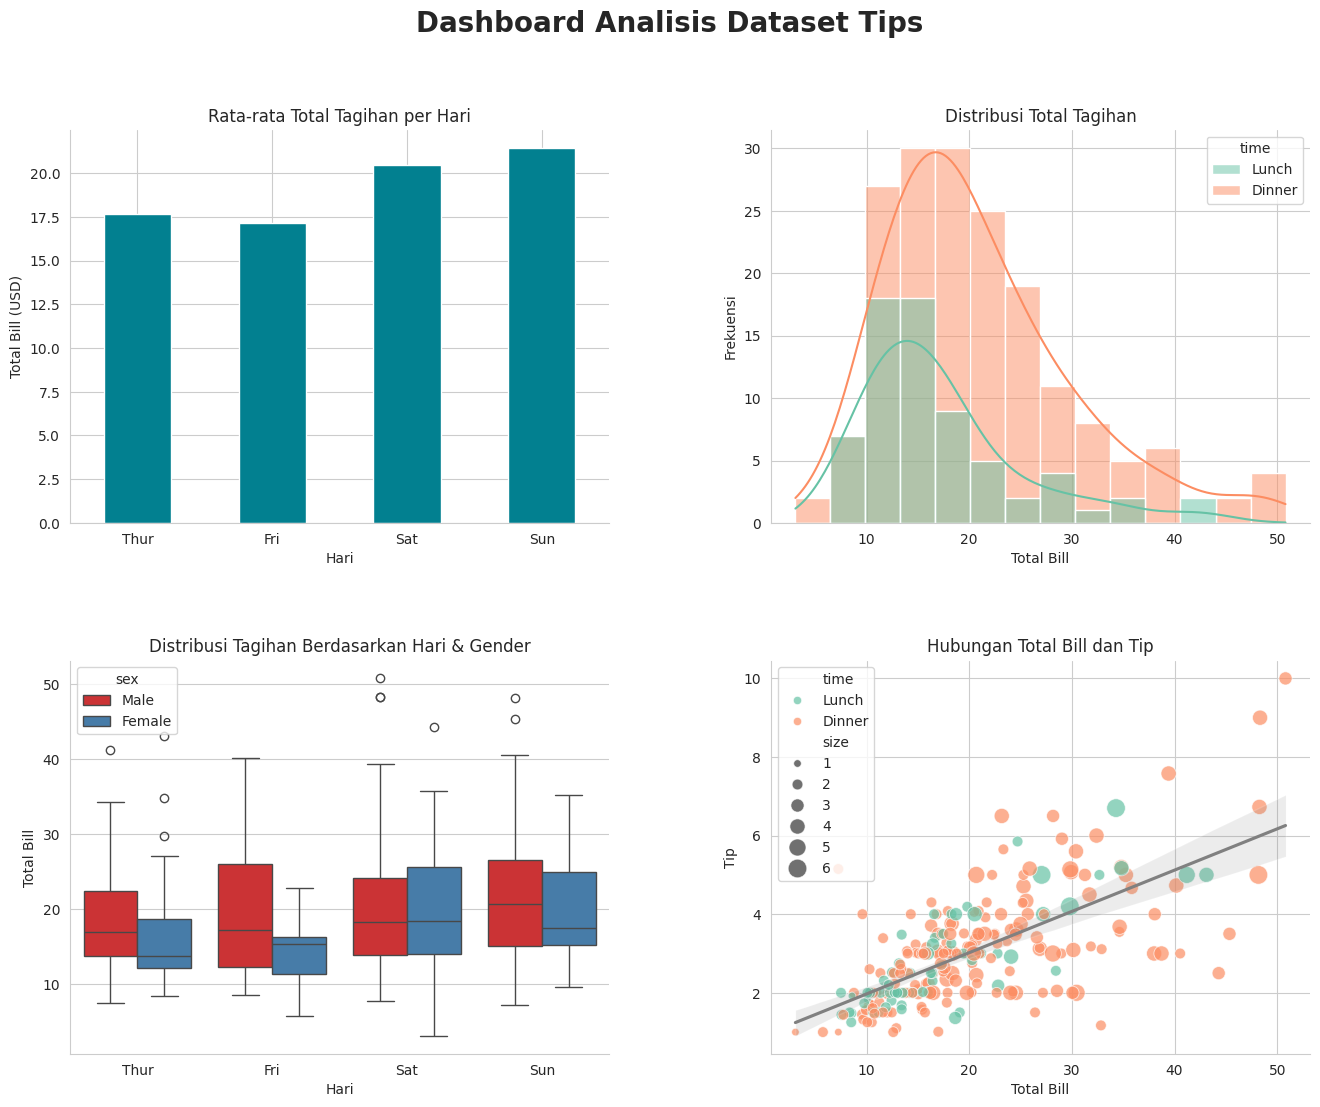

Dashboard berhasil disimpan sebagai dashboard_tips.png


In [1]:
# ── IMPORT LIBRARY ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── LOAD DATASET ───────────────────────────────────────────────
df = sns.load_dataset('tips')

# ── INSPEKSI DATA ──────────────────────────────────────────────
print("Ukuran Dataset :", df.shape)
print("\nTipe Data:")
print(df.dtypes)

print("\nStatistik Deskriptif:")
print(df.describe().round(2))

# ── SET STYLE ──────────────────────────────────────────────────
sns.set_style("whitegrid")

# ── MEMBUAT DASHBOARD ──────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))

fig.suptitle(
    'Dashboard Analisis Dataset Tips',
    fontsize=20,
    fontweight='bold',
    y=0.98
)

# Grid layout 2x2
gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.35,
    wspace=0.30
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ── GRAFIK 1 : BAR CHART ──────────────────────────────────────
avg_by_day = df.groupby('day')['total_bill'].mean()

avg_by_day.plot(
    kind='bar',
    ax=ax1,
    color='#028090',
    edgecolor='white'
)

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)

# ── GRAFIK 2 : HISTOGRAM ──────────────────────────────────────
sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Distribusi Total Tagihan')
ax2.set_xlabel('Total Bill')
ax2.set_ylabel('Frekuensi')

# ── GRAFIK 3 : BOXPLOT ────────────────────────────────────────
sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex',
    palette='Set1',
    ax=ax3
)

ax3.set_title('Distribusi Tagihan Berdasarkan Hari & Gender')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill')

# ── GRAFIK 4 : SCATTER PLOT ───────────────────────────────────
sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 180),
    palette='Set2',
    alpha=0.7,
    ax=ax4
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray',
    ax=ax4
)

ax4.set_title('Hubungan Total Bill dan Tip')
ax4.set_xlabel('Total Bill')
ax4.set_ylabel('Tip')

# ── RAPIIKAN TAMPILAN ─────────────────────────────────────────
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines[['top', 'right']].set_visible(False)

# ── SIMPAN GAMBAR ─────────────────────────────────────────────
plt.savefig(
    'dashboard_tips.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Dashboard berhasil disimpan sebagai dashboard_tips.png")